In [637]:
#Steps of Analysis
#clean the data
#prepare the data for modelling
#modelling
#final Analysis and business recommendation



In [638]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [639]:
#read the dataset
retail_df=pd.read_csv('Online+Retail (1).csv',sep=",",encoding="ISO-8859-1",header=0)

In [640]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [641]:
retail_df.shape

(541909, 8)

In [642]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [643]:
#checking for missing values
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [644]:
(100*retail_df.isnull().sum()/len(retail_df),2)

(InvoiceNo       0.000000
 StockCode       0.000000
 Description     0.268311
 Quantity        0.000000
 InvoiceDate     0.000000
 UnitPrice       0.000000
 CustomerID     24.926694
 Country         0.000000
 dtype: float64,
 2)

In [645]:
#drop all rows having missing values
retail_df=retail_df.dropna()

In [646]:
retail_df.shape

(406829, 8)

In [647]:
# R- Recency
# F- Frequency
# M- mhonetary
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [648]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [649]:
#adding a new column amount
retail_df['Amount']= retail_df['Quantity'] * retail_df['UnitPrice']

In [650]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [651]:
#amount by each customer
retail_df.groupby('CustomerID')['Amount'].sum()

CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: Amount, Length: 4372, dtype: float64

In [652]:
#monetary value
group_df=retail_df.groupby('CustomerID')['Amount'].sum()
group_df=group_df.reset_index()


In [653]:
group_df.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [654]:
group_df.shape

(4372, 2)

In [655]:
#frequency value
frequency_df=retail_df.groupby('CustomerID')['InvoiceNo'].count()
frequency_df=frequency_df.reset_index()


In [656]:
frequency_df.columns=['CustomerID','frequency']

In [657]:
frequency_df

,CustomerID,frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4367,18280.0,10
4368,18281.0,7
4369,18282.0,13
4370,18283.0,756


In [658]:
#merging 2 dataframe
group_df=pd.merge(group_df,frequency_df,on='CustomerID',how='inner')

In [659]:
group_df.head()

,CustomerID,Amount,frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [660]:
group_df

,CustomerID,Amount,frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


In [661]:
#receny
#converting to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'], format="%d-%m-%Y %H:%M")

In [662]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
 8   Amount       406829 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


In [663]:
#computing max date
max_Date=max(retail_df['InvoiceDate'])

In [664]:
max_Date

Timestamp('2011-12-09 12:50:00')

In [665]:
#computing the difference between max date and retail df for calculating recency
retail_df['diff']=max_Date-retail_df['InvoiceDate']

In [666]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [667]:
#recency
latest_purchase=retail_df.groupby('CustomerID')['diff'].min()
latest_purchase

CustomerID
12346.0   325 days 02:33:00
12347.0     1 days 20:58:00
12348.0    74 days 23:37:00
12349.0    18 days 02:59:00
12350.0   309 days 20:49:00
                 ...       
18280.0   277 days 02:58:00
18281.0   180 days 01:57:00
18282.0     7 days 01:07:00
18283.0     3 days 00:48:00
18287.0    42 days 03:21:00
Name: diff, Length: 4372, dtype: timedelta64[ns]

In [668]:
latest_purchase.reset_index()

,CustomerID,diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00
...,...,...
4367,18280.0,277 days 02:58:00
4368,18281.0,180 days 01:57:00
4369,18282.0,7 days 01:07:00
4370,18283.0,3 days 00:48:00


In [669]:
latest_purchase

CustomerID
12346.0   325 days 02:33:00
12347.0     1 days 20:58:00
12348.0    74 days 23:37:00
12349.0    18 days 02:59:00
12350.0   309 days 20:49:00
                 ...       
18280.0   277 days 02:58:00
18281.0   180 days 01:57:00
18282.0     7 days 01:07:00
18283.0     3 days 00:48:00
18287.0    42 days 03:21:00
Name: diff, Length: 4372, dtype: timedelta64[ns]

In [670]:
group_df

,CustomerID,Amount,frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


In [671]:
group_df=pd.merge(group_df,latest_purchase,on='CustomerID',how='inner')

In [672]:
group_df.columns=['CustomerId','Amount','frequency','recency']

In [673]:
group_df.head()

,CustomerId,Amount,frequency,recency
0,12346.0,0.00,2,325 days 02:33:00
1,12347.0,4310.00,182,1 days 20:58:00
2,12348.0,1797.24,31,74 days 23:37:00
3,12349.0,1757.55,73,18 days 02:59:00
4,12350.0,334.40,17,309 days 20:49:00


In [674]:
import datetime as dt

In [675]:
group_df['recency']=group_df['recency'].dt.days

In [676]:
group_df.head()

,CustomerId,Amount,frequency,recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


{'whiskers': [<matplotlib.lines.Line2D at 0x181a00d3b60>,
 'caps': [<matplotlib.lines.Line2D at 0x181a05e4170>,
 'boxes': [<matplotlib.lines.Line2D at 0x181a00d38c0>],
 'medians': [<matplotlib.lines.Line2D at 0x181a05e4710>],
 'fliers': [<matplotlib.lines.Line2D at 0x181a05e4a40>],
 'means': []}

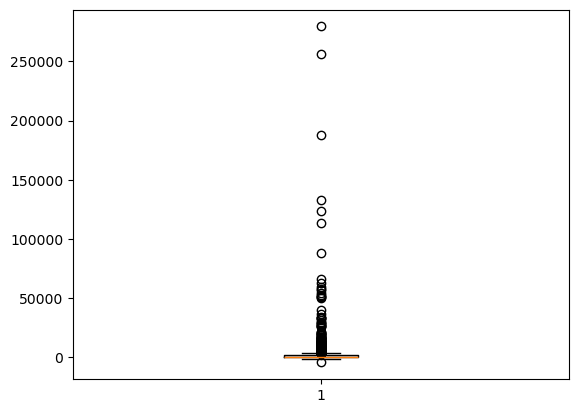

In [677]:
plt.boxplot(group_df['Amount'])

{'whiskers': [<matplotlib.lines.Line2D at 0x181a05b2600>,
 'caps': [<matplotlib.lines.Line2D at 0x181a05b2ab0>,
 'boxes': [<matplotlib.lines.Line2D at 0x181a05b2360>],
 'medians': [<matplotlib.lines.Line2D at 0x181a05b3080>],
 'fliers': [<matplotlib.lines.Line2D at 0x181a05b33b0>],
 'means': []}

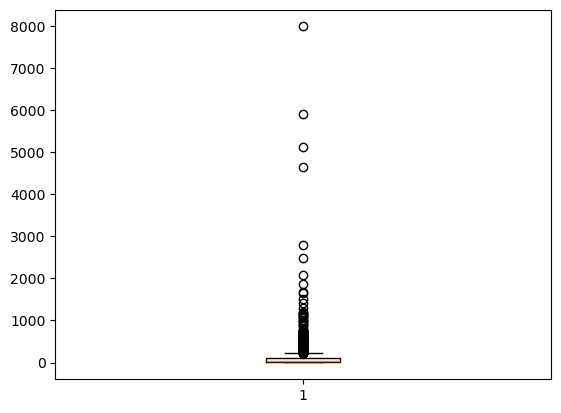

In [678]:
plt.boxplot(group_df['frequency'])

{'whiskers': [<matplotlib.lines.Line2D at 0x181a33724b0>,
 'caps': [<matplotlib.lines.Line2D at 0x181a33729f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x181a3372240>],
 'medians': [<matplotlib.lines.Line2D at 0x181a3372fc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x181a33732f0>],
 'means': []}

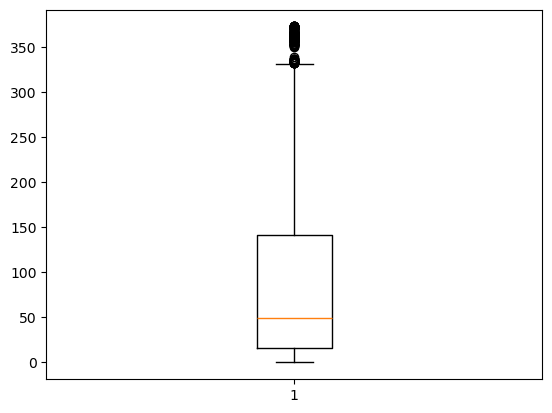

In [679]:
plt.boxplot(group_df['recency'])

In [680]:
Q1=group_df.Amount.quantile(0.05)
Q3=group_df.Amount.quantile(0.95)
IQR=Q3-Q1

group_df=group_df[ ( group_df.Amount>= Q1 - 1.5 * IQR ) & ( group_df.Amount<=Q3+1.5*IQR )]

Q1=group_df.frequency.quantile(0.05)
Q3=group_df.frequency.quantile(0.95)
IQR=Q3-Q1
group_df=group_df[ ( group_df.frequency>= Q1 - 1.5 * IQR ) & ( group_df.frequency<=Q3+1.5*IQR )]

Q1=group_df.recency.quantile(0.05)
Q3=group_df.recency.quantile(0.95)
IQR=Q3-Q1
group_df=group_df[ ( group_df.recency>= Q1 - 1.5 * IQR ) & ( group_df.recency<=Q3+1.5*IQR )]

In [681]:
group_df

,CustomerId,Amount,frequency,recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309
...,...,...,...,...
4366,18278.0,173.90,9,73
4367,18280.0,180.60,10,277
4368,18281.0,80.82,7,180
4369,18282.0,176.60,13,7


In [682]:
from sklearn.preprocessing import StandardScaler

In [683]:
rfm_df=group_df[['Amount','frequency','recency']]
scaler=StandardScaler()

In [684]:
scaler

StandardScaler()

In [685]:
rfm_df_scaled=scaler.fit_transform(rfm_df)

In [686]:
rfm_df_scaled

array([[-0.72373821, -0.75288754,  2.30161144],
       [ 1.73161722,  1.04246665, -0.90646561],
       [ 0.30012791, -0.46363604, -0.18365813],
       ...,
       [-0.67769602, -0.70301659,  0.86589794],
       [-0.6231313 , -0.64317145, -0.84705678],
       [ 0.32293822, -0.07464263, -0.50050524]])

In [687]:
rfm_df_scaled.shape

(4293, 3)

In [688]:
#Modelling
rfm_df_scaled=pd.DataFrame(rfm_df_scaled)

In [689]:
rfm_df_scaled.columns=['Amount','frequency','recency']

In [690]:
rfm_df_scaled.head()

,Amount,frequency,recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


In [691]:
from sklearn.cluster import KMeans

In [692]:
#k means with some arbitrary k
kmean=KMeans(n_clusters=4,max_iter=50)

In [693]:
kmean

KMeans(max_iter=50, n_clusters=4)

In [694]:
kmean.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=4)

In [695]:
len(kmean.labels_)

4293

In [696]:
#finding optimal number of clusters
#elbow curve
ssd=[]
range_n_clusters=[2,3,4,5,6,7,8]

for i in range_n_clusters:
    kmeans=KMeans(max_iter=50,n_clusters=i)
    kmeans.fit(rfm_df_scaled)
    ssd.append(kmeans.inertia_)

#plot  the SSDs for each n_clusters

ssd 

[8703.493695588299,
 4433.7476893476205,
 3962.8148002194043,
 2803.5002537784217,
 2392.1500241643257,
 2218.429393743432,
 1829.998067692672]

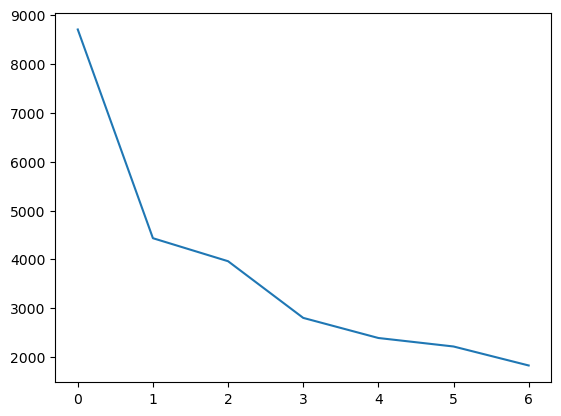

In [697]:
plt.plot(ssd)

In [698]:
#silhoutte Analysis
from sklearn.metrics import silhouette_score

range_n_clusters=[2,3,4,5,6,7,8]

for i in range_n_clusters:
    kmeans=KMeans(n_clusters=i,max_iter=50)
    kmeans.fit(rfm_df_scaled)
    silhouette_avg=silhouette_score(rfm_df_scaled,kmeans.labels_)
    print("for n clusters={0}, the silhoutte score is {1}".format(i,silhouette_avg))

for n clusters=2, the silhoutte score is 0.5389790406760827
for n clusters=3, the silhoutte score is 0.5085084004374336
for n clusters=4, the silhoutte score is 0.4777820100216849
for n clusters=5, the silhoutte score is 0.46627005641897035
for n clusters=6, the silhoutte score is 0.41698547252648926
for n clusters=7, the silhoutte score is 0.3864026036008954
for n clusters=8, the silhoutte score is 0.3879594558057553


In [699]:
kmeans=KMeans(n_clusters=3,max_iter=50)
kmeans.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=3)

In [700]:
len(kmeans.labels_)

4293

In [704]:
group_df['Cluster_id']=kmeans.labels_

In [705]:
group_df.head()

,CustomerId,Amount,frequency,recency,Cluster_id
0,12346.0,0.00,2,325,1
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,1


C:\Users\91996\AppData\Local\Temp\ipykernel_16996\834538206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_id',y='Amount',data=group_df,palette="Set1")


<Axes: xlabel='Cluster_id', ylabel='Amount'>

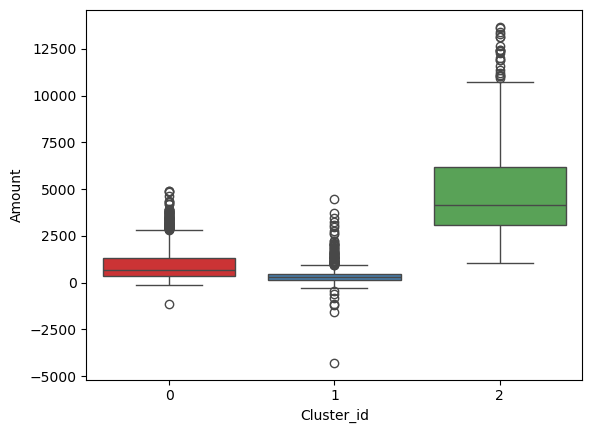

In [706]:
#sns
sns.boxplot(x='Cluster_id',y='Amount',data=group_df,palette="Set1")

C:\Users\91996\AppData\Local\Temp\ipykernel_16996\3133520568.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_id',y='frequency',data=group_df,palette="Set3")


<Axes: xlabel='Cluster_id', ylabel='frequency'>

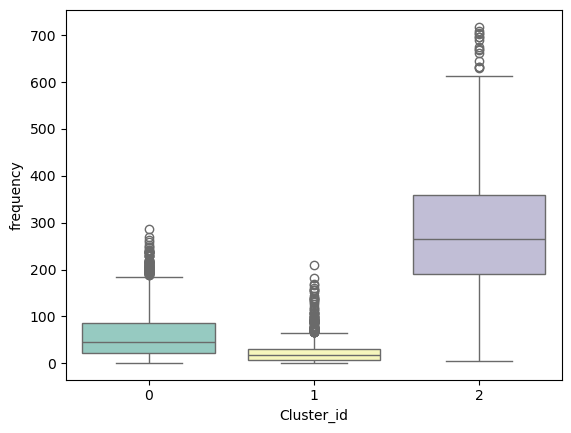

In [707]:
sns.boxplot(x='Cluster_id',y='frequency',data=group_df,palette="Set3")

C:\Users\91996\AppData\Local\Temp\ipykernel_16996\2963099515.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_id',y='recency',data=group_df,palette="Set2")


<Axes: xlabel='Cluster_id', ylabel='recency'>

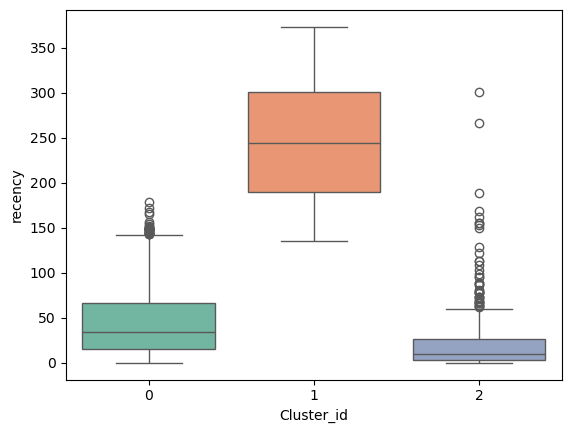

In [708]:
sns.boxplot(x='Cluster_id',y='recency',data=group_df,palette="Set2")